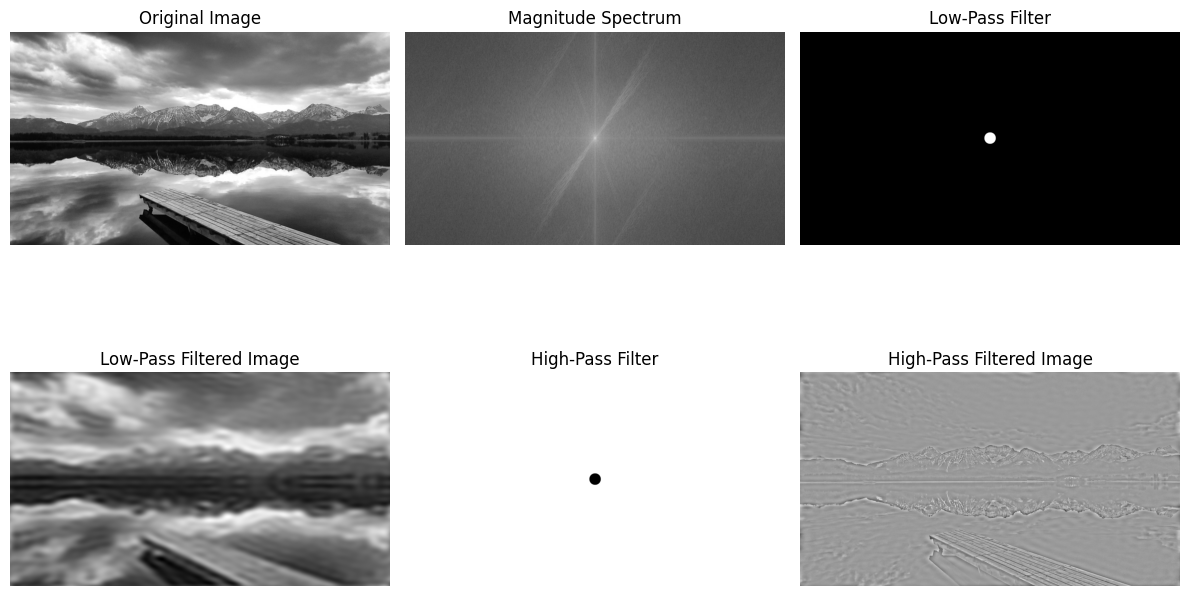

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image
img = cv2.imread("blackk.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Convert image to float for Fourier processing
img_float = np.float32(img)

# 2. Compute 2-D Fourier Transform
dft = np.fft.fft2(img_float)

# Shift zero frequency component to the center
dft_shift = np.fft.fftshift(dft)

# 3. Compute magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

# Normalize magnitude spectrum for display
magnitude_spectrum = cv2.normalize(
    magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# Image dimensions and center
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Filter radius
radius = 30

# 4. Create Low-Pass Filter
low_pass = np.zeros((rows, cols), dtype=np.float32)
cv2.circle(low_pass, (ccol, crow), radius, 1, -1)

# 5. Create High-Pass Filter
high_pass = 1 - low_pass

# 6. Apply filters in frequency domain
low_pass_dft = dft_shift * low_pass
high_pass_dft = dft_shift * high_pass

# 7. Inverse Fourier Transform - Low Pass
low_pass_ishift = np.fft.ifftshift(low_pass_dft)
low_pass_img = np.fft.ifft2(low_pass_ishift)

# Take real part
low_pass_img = np.real(low_pass_img)

# 8. Inverse Fourier Transform - High Pass
high_pass_ishift = np.fft.ifftshift(high_pass_dft)
high_pass_img = np.fft.ifft2(high_pass_ishift)

# Take real part
high_pass_img = np.real(high_pass_img)

# Normalize results for display
low_pass_display = cv2.normalize(
    low_pass_img, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# High-pass image contains positive and negative values,
# so shift/normalize it for visualization
high_pass_display = cv2.normalize(
    high_pass_img, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# Convert filters to uint8 for display
low_pass_display_filter = (low_pass * 255).astype(np.uint8)
high_pass_display_filter = (high_pass * 255).astype(np.uint8)

# 9. Display results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(low_pass_display_filter, cmap="gray")
plt.title("Low-Pass Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(low_pass_display, cmap="gray")
plt.title("Low-Pass Filtered Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(high_pass_display_filter, cmap="gray")
plt.title("High-Pass Filter")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(high_pass_display, cmap="gray")
plt.title("High-Pass Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()